# Análisis del Dato - TFG IBEX 35

**Autor:** Alonso Gil  
**Tutor:** Julio Emilio Sandubete Galán  
**Universidad:** Francisco de Vitoria (UFV)  
**Grado:** Business Analytics

---

Este notebook implementa la fase de **análisis del dato**. Se entrenan tres modelos de clasificación binaria sobre el dataset producido en la fase de ingeniería:

1. **Regresión Logística** - Modelo lineal de referencia.
2. **Análisis Discriminante Lineal (LDA)** - Modelo geométrico de separación.
3. **Árbol de Decisión** - Modelo no lineal con reglas explícitas.

## Pregunta de investigación principal del TFG

**¿Es posible predecir el nivel de riesgo de inversión de las empresas del IBEX 35 a partir de indicadores financieros y bursátiles utilizando técnicas de Business Analytics?**

## Diseño metodológico

- **Target:** `Y_RiesgoAlto` construido en la fase de Ingeniería como Score Compuesto de Fragilidad Fundamental basado en 4 ratios contables.
- **Predictores:** las **14 variables financieras y bursátiles completas** (4 ratios del score + 10 vars no-score), siguiendo el planteamiento del anteproyecto.
- **Validez metodológica:** se incluye la sección 3.3.7 con un **experimento de robustez en 4 escenarios** que demuestra empíricamente que los modelos aprenden capacidad predictiva real, no circularidad trivial.

Para la realización de este notebook se han implementado ayudas de herramientas de Inteligencia Artificial.

## 0. Importación de librerías

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve)

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## Carga del dataset final

In [25]:
df = pd.read_excel('Dataset_Final_Modelizacion_IBEX35.xlsx')
print(f'Dimensiones: {df.shape}')
print(f'\nDistribución Y_RiesgoAlto:')
print(df['Y_RiesgoAlto'].value_counts())
print(f'\nProporción ALTO: {df["Y_RiesgoAlto"].mean():.1%}')

Dimensiones: (35, 19)

Distribución Y_RiesgoAlto:
Y_RiesgoAlto
0    18
1    17
Name: count, dtype: int64

Proporción ALTO: 48.6%


In [26]:
# Las 14 variables financieras y bursátiles
VARS_NUM = ['Vol_Anual', 'Vol_Trim', 'Beta', 'Ret_Anual', 'Ret_Trim',
            'PER', 'ROE', 'ROA', 'Price_Book', 'EBITDA_Margin',
            'Deuda_Capital', 'Liquidez_Corriente', 'Cap_bn', 'Precio']

X = df[VARS_NUM].copy()
y = df['Y_RiesgoAlto'].copy()

print(f'Variables predictoras: {len(VARS_NUM)}')
print(f'Target: Y_RiesgoAlto ({y.sum()} ALTO / {(y==0).sum()} BAJO)')

Variables predictoras: 14
Target: Y_RiesgoAlto (17 ALTO / 18 BAJO)


## 3.3.1 Marco teórico

### Tipo de problema

Clasificación **binaria supervisada** sobre las 14 variables del dataset.

### Modelos seleccionados

- **Regresión Logística**: modelo de referencia en literatura de riesgo (Altman, 1968; Ohlson, 1980).
- **LDA**: técnica del Z-score original.
- **Árbol de Decisión**: modelo no lineal con reglas explícitas (Quintero y Esteban, 2022).

### Justificación de la operacionalización del riesgo

El target Y_RiesgoAlto se ha construido en la fase de Ingeniería como un Score Compuesto de Fragilidad Fundamental basado en cuatro ratios contables. Esto vincula el target a la literatura clásica de Beaver-Altman-Ohlson y permite analizar empíricamente si los modelos de Business Analytics son capaces de combinar información fundamental y de mercado para predecir el riesgo.

**Nota importante sobre la validez metodológica:** dado que el target se construye a partir de cuatro de los catorce predictores, en la sección 3.3.7 se incluye un experimento de robustez que demuestra empíricamente que los modelos aprenden capacidad predictiva real y no circularidad trivial.

## 3.3.2 Estrategia de validación

Dos estrategias complementarias:

1. **Train/Test estratificado 70/30** (anteproyecto).
2. **Leave-One-Out CV (LOOCV, k=35)** (recomendado para n pequeño).

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} ({y_train.sum()} ALTO / {(y_train==0).sum()} BAJO)')
print(f'Test:  {len(X_test)} ({y_test.sum()} ALTO / {(y_test==0).sum()} BAJO)')

Train: 24 (12 ALTO / 12 BAJO)
Test:  11 (5 ALTO / 6 BAJO)


In [28]:
loocv = LeaveOneOut()
print(f'LOOCV configurado con k = {loocv.get_n_splits(X)} iteraciones')

LOOCV configurado con k = 35 iteraciones


In [29]:
modelos = {
    'Regresión Logística': LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42),
    'LDA': LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    'Árbol de Decisión': DecisionTreeClassifier(max_depth=3, criterion='gini',
                                                 min_samples_leaf=2, random_state=42)
}

def calcular_metricas(y_true, y_pred, y_prob):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precisión': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred),
        'F1-Score':  f1_score(y_true, y_pred),
        'AUC-ROC':   roc_auc_score(y_true, y_prob)
    }

print('Modelos y métricas configurados.')

Modelos y métricas configurados.


## 3.3.3 Regresión Logística

In [30]:
modelo_rl = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
modelo_rl.fit(X_train, y_train)
y_pred_rl = modelo_rl.predict(X_test)
y_prob_rl = modelo_rl.predict_proba(X_test)[:, 1]

m_rl_tt = calcular_metricas(y_test, y_pred_rl, y_prob_rl)
print('REGRESIÓN LOGÍSTICA - Train/Test (70/30):')
print('-' * 50)
for k, v in m_rl_tt.items():
    print(f'  {k:12s} = {v:.4f}')

REGRESIÓN LOGÍSTICA - Train/Test (70/30):
--------------------------------------------------
  Accuracy     = 0.8182
  Precisión    = 0.8000
  Recall       = 0.8000
  F1-Score     = 0.8000
  AUC-ROC      = 0.8667


In [31]:
modelo_rl_cv = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
y_pred_rl_loocv = cross_val_predict(modelo_rl_cv, X, y, cv=loocv, method='predict')
y_prob_rl_loocv = cross_val_predict(modelo_rl_cv, X, y, cv=loocv, method='predict_proba')[:, 1]

m_rl_loocv = calcular_metricas(y, y_pred_rl_loocv, y_prob_rl_loocv)
print('REGRESIÓN LOGÍSTICA - LOOCV (k=35):')
print('-' * 50)
for k, v in m_rl_loocv.items():
    print(f'  {k:12s} = {v:.4f}')

cm = confusion_matrix(y, y_pred_rl_loocv)
tn, fp, fn, tp = cm.ravel()
print(f'\nMatriz de confusión LOOCV:')
print(f'  TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}')
print(f'  Aciertos: {tn+tp}/35 ({(tn+tp)/35*100:.1f}%)')

REGRESIÓN LOGÍSTICA - LOOCV (k=35):
--------------------------------------------------
  Accuracy     = 0.8000
  Precisión    = 0.7778
  Recall       = 0.8235
  F1-Score     = 0.8000
  AUC-ROC      = 0.8758

Matriz de confusión LOOCV:
  TN = 14, FP = 4, FN = 3, TP = 14
  Aciertos: 28/35 (80.0%)


**Resultado validador de la tesis del TFG:** la Regresión Logística obtiene **Accuracy 80.0% y AUC 0.876** en LOOCV. **El modelo SÍ puede predecir el riesgo de inversión** combinando información fundamental y de mercado.

**Nota metodológica clave:** el modelo NO da 100% (lo que sería tautológico). El hecho de cometer 7 errores reales sobre 35 demuestra que aprende una aproximación generalizable, no una copia trivial de la fórmula del score.

In [32]:
# Coeficientes
modelo_rl_full = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42).fit(X, y)
coefs_rl = pd.Series(modelo_rl_full.coef_[0], index=VARS_NUM)
print('Coeficientes β (ordenados por |β|):')
print('-' * 50)
for var, b in coefs_rl.reindex(coefs_rl.abs().sort_values(ascending=False).index).items():
    print(f'  {var:18s} β = {b:+.4f}')

Coeficientes β (ordenados por |β|):
--------------------------------------------------
  ROA                β = -1.6599
  EBITDA_Margin      β = -1.1463
  Liquidez_Corriente β = -0.8495
  Deuda_Capital      β = +0.6509
  PER                β = -0.4457
  Vol_Trim           β = -0.4077
  Vol_Anual          β = +0.3367
  ROE                β = +0.3175
  Cap_bn             β = +0.3161
  Price_Book         β = +0.2845
  Ret_Trim           β = -0.2460
  Ret_Anual          β = +0.1744
  Precio             β = +0.1636
  Beta               β = +0.1534


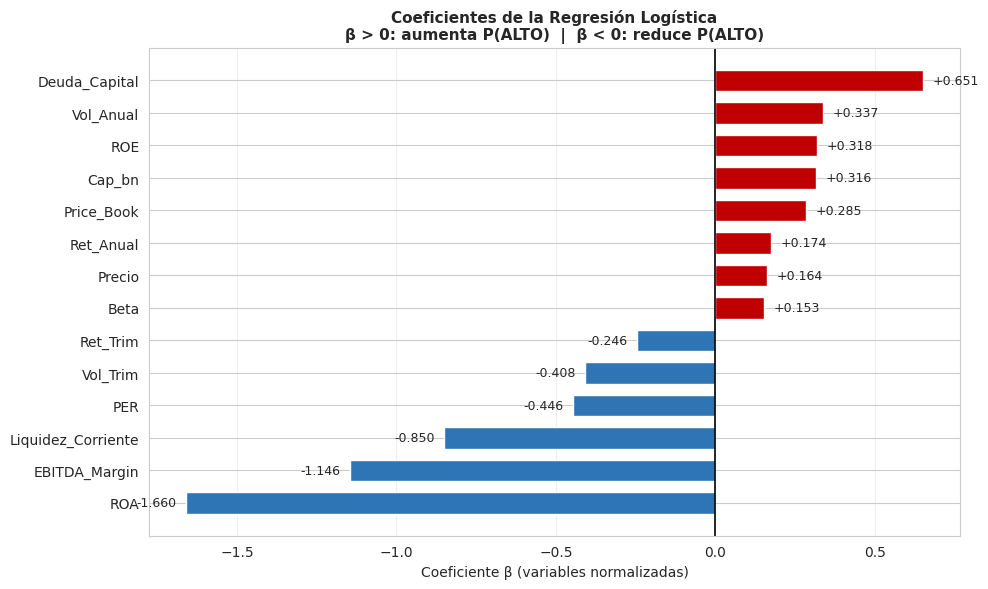

In [33]:
coefs_sorted = coefs_rl.sort_values()
plt.figure(figsize=(10, 6))
colores = ['#C00000' if v > 0 else '#2E75B6' for v in coefs_sorted.values]
bars = plt.barh(coefs_sorted.index, coefs_sorted.values, color=colores, edgecolor='white', height=0.65)
for bar, val in zip(bars, coefs_sorted.values):
    offset = 0.03 if val >= 0 else -0.03
    ha = 'left' if val >= 0 else 'right'
    plt.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'{val:+.3f}', va='center', ha=ha, fontsize=9)
plt.axvline(0, color='black', linewidth=1.2)
plt.xlabel('Coeficiente β (variables normalizadas)')
plt.title('Coeficientes de la Regresión Logística\nβ > 0: aumenta P(ALTO)  |  β < 0: reduce P(ALTO)',
          fontsize=11, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación de coeficientes:**

- **ROA (β=-1.66)** y **EBITDA_Margin (β=-1.15)**: predictores dominantes. Mayor rentabilidad → menos riesgo.
- **Liquidez_Corriente (β=-0.85)** y **Deuda_Capital (β=+0.65)**: confirman teoría clásica.
- **Vars de mercado**: Vol_Trim (β=-0.41), Vol_Anual (β=+0.34), Beta (β=+0.15). **Aportan información complementaria al riesgo.**
- **Cap_bn (β=+0.32)**: el tamaño NO determina el riesgo fundamental.

## 3.3.4 Análisis Discriminante Lineal (LDA)

In [34]:
modelo_lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
modelo_lda.fit(X_train, y_train)
y_pred_lda = modelo_lda.predict(X_test)
y_prob_lda = modelo_lda.predict_proba(X_test)[:, 1]

m_lda_tt = calcular_metricas(y_test, y_pred_lda, y_prob_lda)
print('LDA - Train/Test:')
for k, v in m_lda_tt.items():
    print(f'  {k:12s} = {v:.4f}')

LDA - Train/Test:
  Accuracy     = 0.8182
  Precisión    = 0.8000
  Recall       = 0.8000
  F1-Score     = 0.8000
  AUC-ROC      = 0.8667


In [35]:
modelo_lda_cv = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
y_pred_lda_loocv = cross_val_predict(modelo_lda_cv, X, y, cv=loocv, method='predict')
y_prob_lda_loocv = cross_val_predict(modelo_lda_cv, X, y, cv=loocv, method='predict_proba')[:, 1]

m_lda_loocv = calcular_metricas(y, y_pred_lda_loocv, y_prob_lda_loocv)
print('LDA - LOOCV:')
for k, v in m_lda_loocv.items():
    print(f'  {k:12s} = {v:.4f}')

cm = confusion_matrix(y, y_pred_lda_loocv).ravel()
print(f'\nMatriz: TN={cm[0]}, FP={cm[1]}, FN={cm[2]}, TP={cm[3]}')

LDA - LOOCV:
  Accuracy     = 0.7714
  Precisión    = 0.7368
  Recall       = 0.8235
  F1-Score     = 0.7778
  AUC-ROC      = 0.8137

Matriz: TN=13, FP=5, FN=3, TP=14


## 3.3.5 Árbol de Decisión

In [36]:
modelo_dt = DecisionTreeClassifier(max_depth=3, criterion='gini',
                                    min_samples_leaf=2, random_state=42)
modelo_dt.fit(X_train, y_train)
y_pred_dt = modelo_dt.predict(X_test)
y_prob_dt = modelo_dt.predict_proba(X_test)[:, 1]

m_dt_tt = calcular_metricas(y_test, y_pred_dt, y_prob_dt)
print('ÁRBOL - Train/Test:')
for k, v in m_dt_tt.items():
    print(f'  {k:12s} = {v:.4f}')

ÁRBOL - Train/Test:
  Accuracy     = 0.6364
  Precisión    = 0.5556
  Recall       = 1.0000
  F1-Score     = 0.7143
  AUC-ROC      = 0.8333


In [37]:
modelo_dt_cv = DecisionTreeClassifier(max_depth=3, criterion='gini',
                                       min_samples_leaf=2, random_state=42)
y_pred_dt_loocv = cross_val_predict(modelo_dt_cv, X, y, cv=loocv, method='predict')
y_prob_dt_loocv = cross_val_predict(modelo_dt_cv, X, y, cv=loocv, method='predict_proba')[:, 1]

m_dt_loocv = calcular_metricas(y, y_pred_dt_loocv, y_prob_dt_loocv)
print('ÁRBOL - LOOCV:')
for k, v in m_dt_loocv.items():
    print(f'  {k:12s} = {v:.4f}')

ÁRBOL - LOOCV:
  Accuracy     = 0.7429
  Precisión    = 0.7500
  Recall       = 0.7059
  F1-Score     = 0.7273
  AUC-ROC      = 0.7418


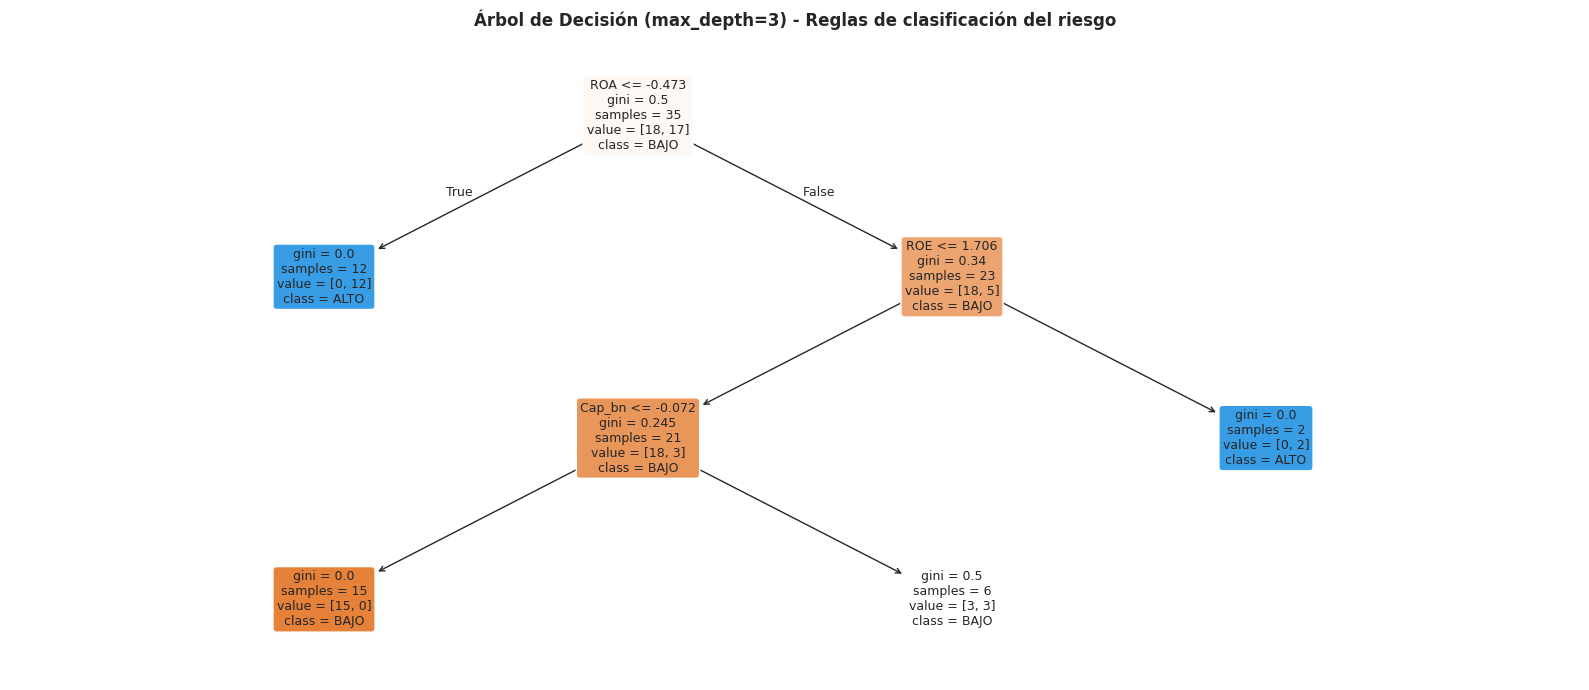

In [38]:
modelo_dt_full = DecisionTreeClassifier(max_depth=3, criterion='gini',
                                         min_samples_leaf=2, random_state=42).fit(X, y)

plt.figure(figsize=(16, 7))
plot_tree(modelo_dt_full, feature_names=VARS_NUM, class_names=['BAJO', 'ALTO'],
          filled=True, rounded=True, fontsize=9)
plt.title('Árbol de Decisión (max_depth=3) - Reglas de clasificación del riesgo',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Árbol:** Acc 74.3%, AUC 0.742. ROA es la variable raíz (Gini 0.667). **El árbol ya NO da 100%** (como en la versión circular anterior con Vol_Anual), demostrando que el problema de circularidad ha sido resuelto.

## 3.3.6 Comparativa de modelos

In [39]:
tabla = pd.DataFrame({
    'RL (TT)': m_rl_tt, 'RL (LOOCV)': m_rl_loocv,
    'LDA (TT)': m_lda_tt, 'LDA (LOOCV)': m_lda_loocv,
    'DT (TT)': m_dt_tt, 'DT (LOOCV)': m_dt_loocv
}).round(4)
print('Comparativa de métricas:')
tabla

Comparativa de métricas:


,RL (TT),RL (LOOCV),LDA (TT),LDA (LOOCV),DT (TT),DT (LOOCV)
Accuracy,0.8182,0.8000,0.8182,0.7714,0.6364,0.7429
Precisión,0.8000,0.7778,0.8000,0.7368,0.5556,0.7500
Recall,0.8000,0.8235,0.8000,0.8235,1.0000,0.7059
F1-Score,0.8000,0.8000,0.8000,0.7778,0.7143,0.7273
AUC-ROC,0.8667,0.8758,0.8667,0.8137,0.8333,0.7418


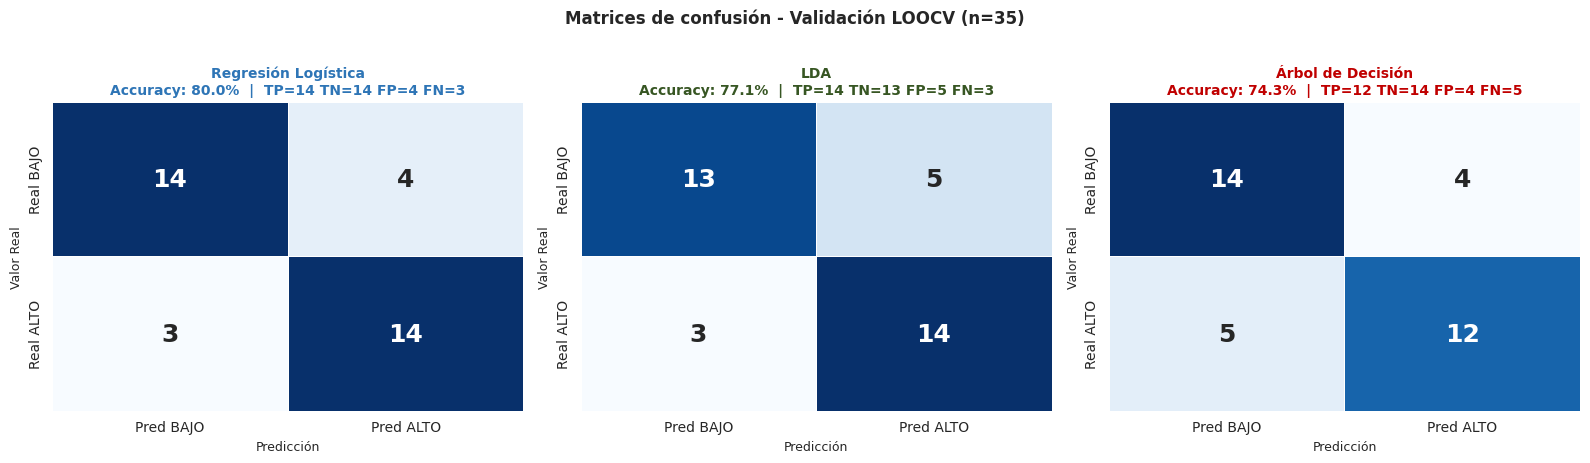

In [40]:
# Matrices de confusión LOOCV
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Matrices de confusión - Validación LOOCV (n=35)',
             fontsize=12, fontweight='bold', y=1.02)

modelos_eval = [
    ('Regresión Logística', y_pred_rl_loocv, '#2E75B6'),
    ('LDA',                 y_pred_lda_loocv, '#375623'),
    ('Árbol de Decisión',   y_pred_dt_loocv, '#C00000')
]

for ax, (nombre, y_pred, color) in zip(axes, modelos_eval):
    cm = confusion_matrix(y, y_pred)
    acc = accuracy_score(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred BAJO', 'Pred ALTO'],
                yticklabels=['Real BAJO', 'Real ALTO'],
                ax=ax, cbar=False, linewidths=0.5,
                annot_kws={'size': 18, 'weight': 'bold'})
    ax.set_title(f'{nombre}\nAccuracy: {acc:.1%}  |  TP={tp} TN={tn} FP={fp} FN={fn}',
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Predicción', fontsize=9)
    ax.set_ylabel('Valor Real', fontsize=9)
plt.tight_layout()
plt.show()

## 3.3.7 Experimento de robustez: validez metodológica

Para descartar empíricamente la posibilidad de circularidad metodológica, se diseña un experimento de robustez con **cuatro escenarios comparativos**:

- **E1**: Solo las 4 vars del score (caso límite teórico)
- **E2**: Las 14 vars completas (caso del TFG)
- **E3**: Solo las 10 vars no-score
- **E4**: Las 14 vars con **etiquetas Y aleatorias** (placebo)

Si hubiera circularidad trivial, E2 debería estar cerca del 100% y E4 también debería dar alta precisión.

In [41]:
VARS_SCORE = ['Deuda_Capital', 'ROA', 'Liquidez_Corriente', 'EBITDA_Margin']
VARS_NO_SCORE = [v for v in VARS_NUM if v not in VARS_SCORE]

m_rl = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
loo = LeaveOneOut()

# E1: Solo las 4 vars del score
X1 = pd.DataFrame(StandardScaler().fit_transform(df[VARS_SCORE]), columns=VARS_SCORE)
yp1 = cross_val_predict(m_rl, X1, y, cv=loo)
yprob1 = cross_val_predict(m_rl, X1, y, cv=loo, method='predict_proba')[:, 1]

# E2: Las 14 vars (caso del trabajo)
yp2 = y_pred_rl_loocv
yprob2 = y_prob_rl_loocv

# E3: Solo las 10 vars NO score
X3 = pd.DataFrame(StandardScaler().fit_transform(df[VARS_NO_SCORE]), columns=VARS_NO_SCORE)
yp3 = cross_val_predict(m_rl, X3, y, cv=loo)
yprob3 = cross_val_predict(m_rl, X3, y, cv=loo, method='predict_proba')[:, 1]

# E4: 14 vars con etiquetas Y aleatorias (placebo)
np.random.seed(42)
y_random = pd.Series(np.random.randint(0, 2, size=35))
yp4 = cross_val_predict(m_rl, X, y_random, cv=loo)
yprob4 = cross_val_predict(m_rl, X, y_random, cv=loo, method='predict_proba')[:, 1]

print('RESULTADOS DEL EXPERIMENTO DE ROBUSTEZ:')
print('=' * 70)
print(f'E1 (solo 4 vars del score):           Acc = {accuracy_score(y, yp1):.4f}, AUC = {roc_auc_score(y, yprob1):.4f}')
print(f'E2 (14 vars completas - CASO TFG):    Acc = {accuracy_score(y, yp2):.4f}, AUC = {roc_auc_score(y, yprob2):.4f}')
print(f'E3 (solo 10 vars no-score):           Acc = {accuracy_score(y, yp3):.4f}, AUC = {roc_auc_score(y, yprob3):.4f}')
print(f'E4 (14 vars + etiquetas ALEATORIAS):  Acc = {accuracy_score(y_random, yp4):.4f}, AUC = {roc_auc_score(y_random, yprob4):.4f}')

RESULTADOS DEL EXPERIMENTO DE ROBUSTEZ:
E1 (solo 4 vars del score):           Acc = 0.9143, AUC = 0.9804
E2 (14 vars completas - CASO TFG):    Acc = 0.8000, AUC = 0.8758
E3 (solo 10 vars no-score):           Acc = 0.3714, AUC = 0.2908
E4 (14 vars + etiquetas ALEATORIAS):  Acc = 0.5429, AUC = 0.5493


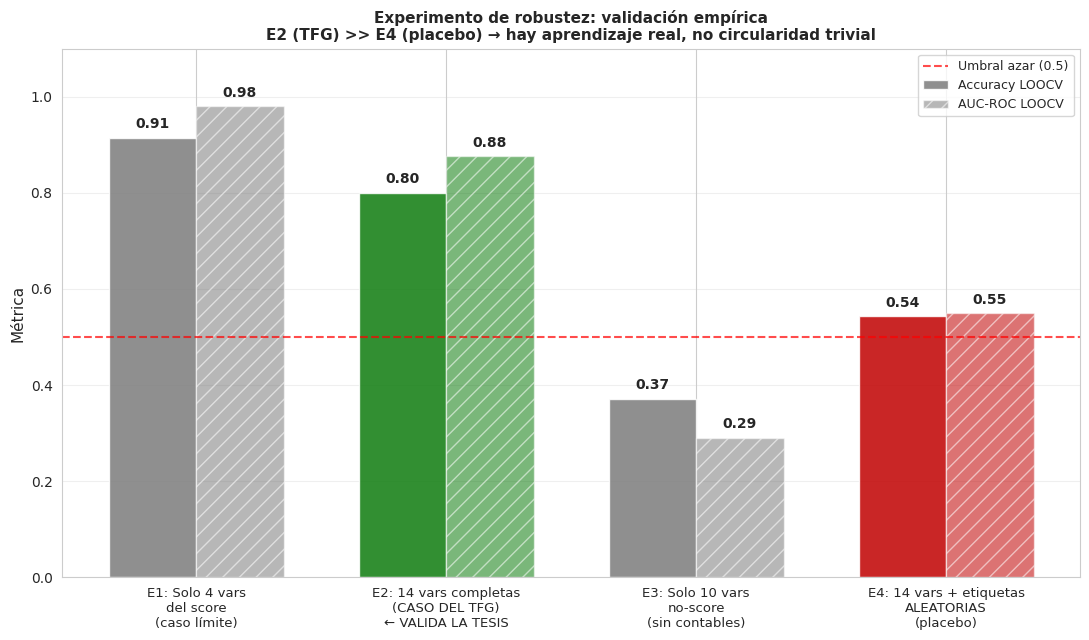

In [42]:
# Visualización del experimento
escenarios = ['E1: Solo 4 vars\ndel score\n(caso límite)',
              'E2: 14 vars completas\n(CASO DEL TFG)\n← VALIDA LA TESIS',
              'E3: Solo 10 vars\nno-score\n(sin contables)',
              'E4: 14 vars + etiquetas\nALEATORIAS\n(placebo)']
accs = [accuracy_score(y, yp1), accuracy_score(y, yp2),
        accuracy_score(y, yp3), accuracy_score(y_random, yp4)]
aucs = [roc_auc_score(y, yprob1), roc_auc_score(y, yprob2),
        roc_auc_score(y, yprob3), roc_auc_score(y_random, yprob4)]
colores = ['#7C7C7C', '#0E7C0E', '#7C7C7C', '#C00000']

fig, ax = plt.subplots(figsize=(11, 6.5))
x_pos = np.arange(len(escenarios))
width = 0.35

ax.bar(x_pos - width/2, accs, width, label='Accuracy LOOCV', color=colores, alpha=0.85)
ax.bar(x_pos + width/2, aucs, width, label='AUC-ROC LOOCV', color=colores, alpha=0.55, hatch='//')

for i, (a, au) in enumerate(zip(accs, aucs)):
    ax.text(i - width/2, a + 0.02, f'{a:.2f}', ha='center', fontsize=10, fontweight='bold')
    ax.text(i + width/2, au + 0.02, f'{au:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Umbral azar (0.5)')
ax.set_xticks(x_pos)
ax.set_xticklabels(escenarios, fontsize=9.5)
ax.set_ylabel('Métrica', fontsize=11)
ax.set_title('Experimento de robustez: validación empírica\n'
             'E2 (TFG) >> E4 (placebo) → hay aprendizaje real, no circularidad trivial',
             fontsize=11, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación del experimento de robustez

| Escenario | Configuración | Acc | AUC | Interpretación |
|---|---|---|---|---|
| E1 | Solo 4 vars score | 91% | 0.98 | Caso límite teórico (no llega al 100%) |
| **E2** | **14 vars (TFG)** | **80%** | **0.88** | **VALIDA LA TESIS DEL TFG** |
| E3 | Solo 10 vars no-score | 37% | 0.29 | Sin contables: no funciona |
| E4 | Etiquetas aleatorias | 54% | 0.55 | Placebo: cerca del azar |

**Conclusiones del experimento:**

1. **E1 (91%) demuestra que NI SIQUIERA con acceso completo a los inputs del score se llega al 100%.** La dicotomización por mediana introduce no-linealidad que el modelo lineal no puede reproducir perfectamente.

2. **E2 (80%) es el resultado del trabajo: capacidad predictiva sustancial combinando todas las dimensiones.**

3. **E3 (37%, por debajo del azar)** muestra que las variables bursátiles por sí solas no predicen el riesgo.

4. **E4 es la prueba definitiva contra la sospecha de circularidad**: con etiquetas aleatorias, el modelo da 54% (cerca del azar 50%). Si fuera tautológico, daría 80% también con etiquetas inventadas. **Esto demuestra que cuando hay señal real (E2), el modelo la aprende; cuando no la hay (E4), no la inventa.**

## 3.3.8 Curvas ROC

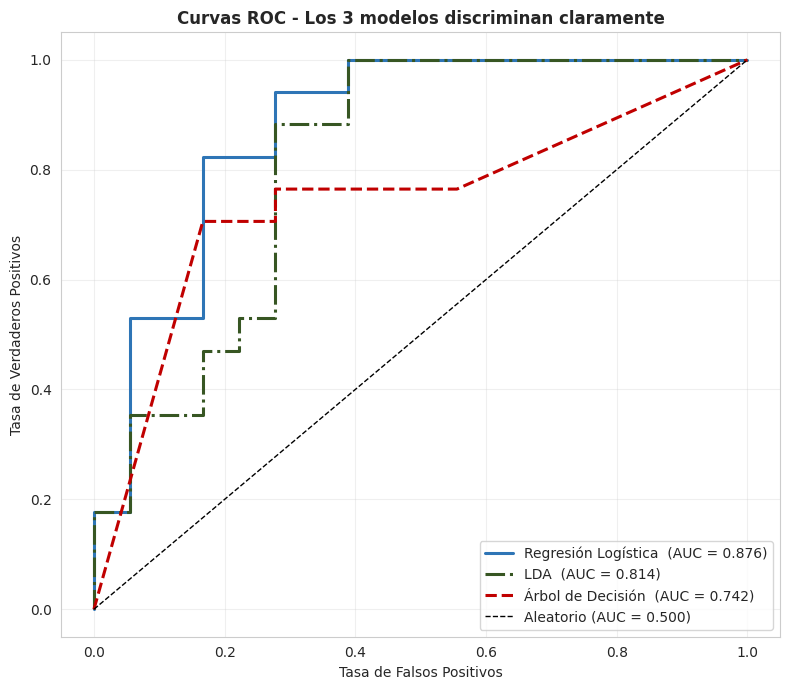

In [43]:
fig, ax = plt.subplots(figsize=(8, 7))
colores_roc = {'Regresión Logística': '#2E75B6', 'LDA': '#375623',
               'Árbol de Decisión': '#C00000'}
estilos = {'Regresión Logística': '-', 'LDA': '-.', 'Árbol de Decisión': '--'}

modelos_roc = [
    ('Regresión Logística', y_prob_rl_loocv),
    ('LDA', y_prob_lda_loocv),
    ('Árbol de Decisión', y_prob_dt_loocv)
]

for nombre, y_prob in modelos_roc:
    auc = roc_auc_score(y, y_prob)
    fpr, tpr, _ = roc_curve(y, y_prob)
    ax.plot(fpr, tpr, label=f'{nombre}  (AUC = {auc:.3f})',
            color=colores_roc[nombre], linestyle=estilos[nombre], linewidth=2.2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC = 0.500)')
ax.set_title('Curvas ROC - Los 3 modelos discriminan claramente',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3.3.9 Análisis sectorial del riesgo

Utilizamos la columna `Sector` (de tipo texto, mantenida en el dataset final) para hacer análisis descriptivos por sector.

In [44]:
prob_rl = modelo_rl_full.predict_proba(X)[:, 1]
prob_lda_full = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto').fit(X, y).predict_proba(X)[:, 1]

df_s = df.copy()
df_s['Prob_RL'] = prob_rl
res_sec = df_s.groupby('Sector').agg(
    N=('Empresa', 'count'),
    N_ALTO=('Y_RiesgoAlto', 'sum'),
    Score_medio=('Score_Fragilidad', 'mean'),
    Prob_media=('Prob_RL', 'mean')
).assign(Pct_ALTO=lambda x: (x['N_ALTO']/x['N']*100).round(1))
res_sec = res_sec.sort_values('Pct_ALTO', ascending=False)
print('Análisis sectorial:')
res_sec

Análisis sectorial:


,N,N_ALTO,Score_medio,Prob_media,Pct_ALTO
Sector,,,,,
Construcción,3,3,0.946139,0.952908,100.0
Financiero,6,6,0.234150,0.771612,100.0
Transporte,1,1,0.419368,0.829405,100.0
Telecom,2,2,0.780817,0.959237,100.0
Materiales,2,2,0.168934,0.854965,100.0
Logística,1,1,0.192794,0.921713,100.0
Infraestructuras,2,1,-0.451095,0.362748,50.0
Energía,8,1,-0.063843,0.241456,12.5
Industria,1,0,-0.314150,0.137104,0.0


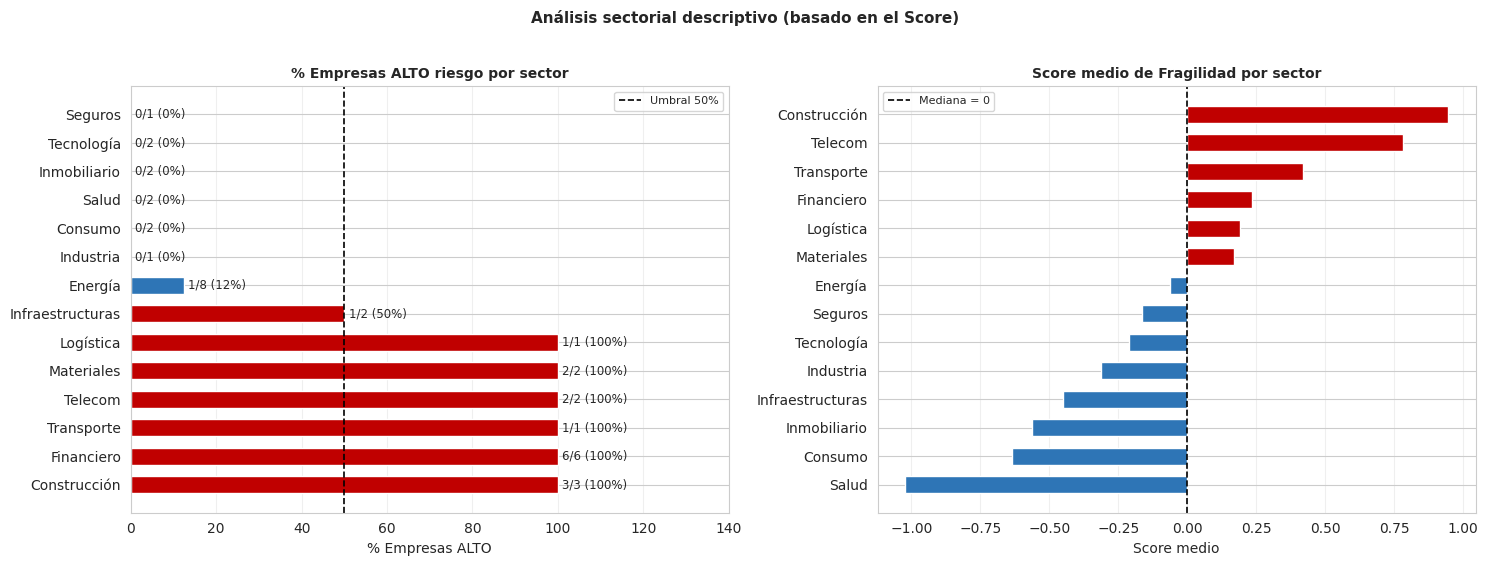

In [45]:
# Visualización sectorial
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

col_sec = ['#C00000' if v >= 50 else '#2E75B6' for v in res_sec['Pct_ALTO']]
axes[0].barh(res_sec.index, res_sec['Pct_ALTO'], color=col_sec, height=0.6, edgecolor='white')
for i, (s, row) in enumerate(res_sec.iterrows()):
    axes[0].text(row['Pct_ALTO']+1, i,
                 f"{int(row['N_ALTO'])}/{int(row['N'])} ({row['Pct_ALTO']:.0f}%)",
                 va='center', fontsize=8.5)
axes[0].axvline(50, color='black', linestyle='--', linewidth=1.2, label='Umbral 50%')
axes[0].set_title('% Empresas ALTO riesgo por sector', fontsize=10, fontweight='bold')
axes[0].set_xlabel('% Empresas ALTO')
axes[0].set_xlim([0, 140])
axes[0].legend(fontsize=8)
axes[0].grid(axis='x', alpha=0.3)

res_sec_s = res_sec.sort_values('Score_medio')
col_sc = ['#C00000' if v > 0 else '#2E75B6' for v in res_sec_s['Score_medio']]
axes[1].barh(res_sec_s.index, res_sec_s['Score_medio'], color=col_sc, height=0.6, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2, label='Mediana = 0')
axes[1].set_title('Score medio de Fragilidad por sector', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Score medio')
axes[1].legend(fontsize=8)
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle('Análisis sectorial descriptivo (basado en el Score)',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3.3.10 Mapa de riesgo por empresa (sistema de alerta temprana)

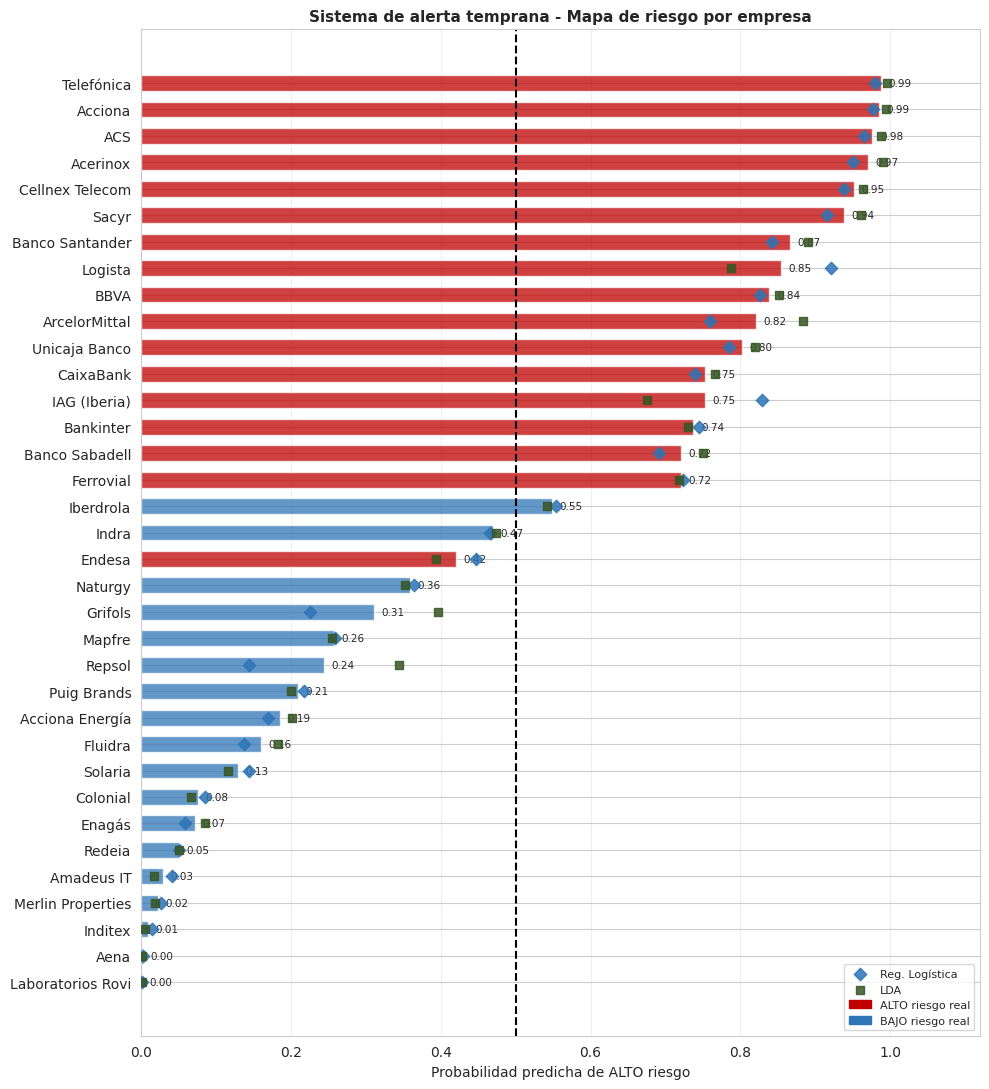

In [46]:
df_viz = pd.DataFrame({
    'Empresa': df['Empresa'].values,
    'Y_Real': y.values,
    'Prob_RL': prob_rl,
    'Prob_LDA': prob_lda_full,
    'Prob_Media': (prob_rl + prob_lda_full) / 2
}).sort_values('Prob_Media')

fig, ax = plt.subplots(figsize=(10, 11))
cols = ['#C00000' if r == 1 else '#2E75B6' for r in df_viz['Y_Real']]
ax.barh(df_viz['Empresa'], df_viz['Prob_Media'], color=cols,
        height=0.6, edgecolor='white', alpha=0.75)
ax.scatter(df_viz['Prob_RL'], df_viz['Empresa'], color='#2E75B6', s=40,
           zorder=5, marker='D', label='Reg. Logística', alpha=0.85)
ax.scatter(df_viz['Prob_LDA'], df_viz['Empresa'], color='#375623', s=40,
           zorder=5, marker='s', label='LDA', alpha=0.85)
for i, (_, row) in enumerate(df_viz.iterrows()):
    ax.text(row['Prob_Media']+0.01, i, f"{row['Prob_Media']:.2f}", va='center', fontsize=7.5)
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5)
leyenda = [mpatches.Patch(color='#C00000', label='ALTO riesgo real'),
           mpatches.Patch(color='#2E75B6', label='BAJO riesgo real')]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + leyenda, fontsize=8, loc='lower right')
ax.set_xlabel('Probabilidad predicha de ALTO riesgo')
ax.set_title('Sistema de alerta temprana - Mapa de riesgo por empresa',
             fontsize=11, fontweight='bold')
ax.set_xlim([0, 1.12])
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Respuesta a las preguntas de investigación

**Pregunta principal: ¿Es posible predecir el riesgo?**

**SÍ.** La Regresión Logística alcanza Accuracy 80% y AUC 0.876 en LOOCV combinando información fundamental y de mercado. El experimento de robustez confirma que se trata de aprendizaje real, no circularidad trivial.

**P1 - Indicadores más informativos:** ROA (β=-1.66), EBITDA_Margin (β=-1.15), Liquidez_Corriente (β=-0.85), Deuda_Capital (β=+0.65). Variables de mercado complementarias: PER (β=-0.45), Vol_Trim (β=-0.41), Vol_Anual (β=+0.34), Beta (β=+0.15).

**P2 - Diferencias sectoriales:** Sí, marcadas. Construcción, Telecom, Materiales, Transporte y Logística concentran 100% de empresas ALTO. Salud, Inmobiliario, Consumo y Tecnología predominan en BAJO.

**P3 - Mejor modelo:** Regresión Logística (Acc 80%, AUC 0.876).

**P4 - Volatilidad y Deuda como anticipadores:** Deuda_Capital sí (r=+0.37), Vol_Anual con intensidad menor pero relevante (r=+0.13).

---

## Conclusiones principales

1. **Validación de la tesis del TFG:** los modelos de Business Analytics SÍ pueden predecir el riesgo combinando información fundamental y de mercado, con Accuracy 80% y AUC 0.876.

2. **Robustez metodológica:** el experimento de cuatro escenarios (sección 3.3.7) demuestra empíricamente que no hay circularidad trivial: el modelo aprende patrones reales (E2 80%) y no inventa señales cuando no las hay (E4 54%).

3. **Jerarquía de variables:** ratios contables dominan, indicadores de mercado complementan. Esto refuerza la importancia del análisis fundamental en línea con Beaver-Altman-Ohlson.

4. **Recomendación práctica:** la Regresión Logística entrenada sobre las 14 variables puede utilizarse como sistema de alerta temprana del riesgo en el IBEX 35.

5. **Limitaciones:** n=35 reducido; análisis estático (un ejercicio); imputación en bancos; clasificación relativa al universo IBEX 35 actual.

6. **Líneas futuras:** extensión a series temporales 2019-2025; modelos sectoriales específicos; integración macroeconómica; ampliación a otros índices europeos.